In [454]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [455]:
train_df = pd.read_csv('data/train.csv').drop(columns='id')
test_df = pd.read_csv('data/test.csv')

In [456]:
le = LabelEncoder()
scaler = StandardScaler()

In [457]:
train_df.head(10)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0
9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0


In [458]:
train_df = train_df.drop(columns='Driver')

<Axes: ylabel='LapTime_Delta'>

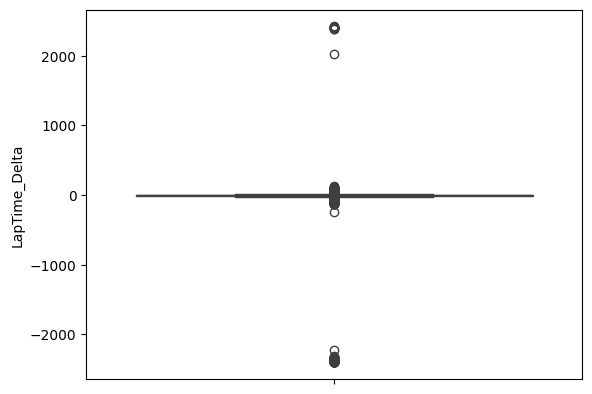

In [459]:
sns.boxplot(train_df['LapTime_Delta'])

In [460]:
train_df = train_df.query('LapTime_Delta <= 1000 & LapTime_Delta >= -200')

<Axes: ylabel='LapTime_Delta'>

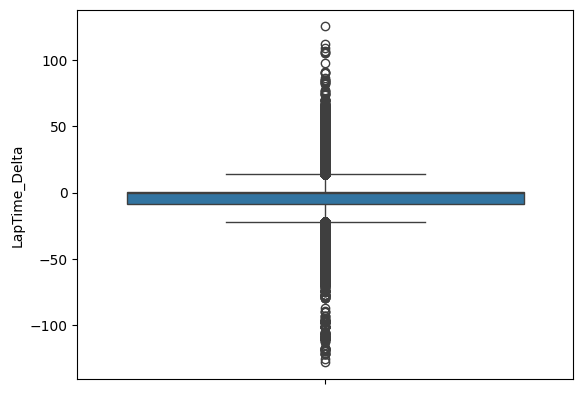

In [461]:
sns.boxplot(train_df['LapTime_Delta'])

In [462]:
train_df['isNegativeDelta'] = (train_df['LapTime_Delta'] < 0).astype(int)

train_df['LapTime_Delta'] = train_df['LapTime_Delta'].abs()

In [463]:
train_df['isNegativeCumulativeDegrad'] = (train_df['Cumulative_Degradation'] < 0).astype(int)

train_df['Cumulative_Degradation'] = train_df['Cumulative_Degradation'].abs()

In [464]:
train_df['isNegativePositionChange'] = (train_df['Position_Change'] < 0).astype(int)

train_df['Position_Change'] = train_df['Position_Change'].abs()

In [465]:
train_df['PitNextLap'] = train_df['PitNextLap'].astype(int)
train_df['Position_Change'] = train_df['Position_Change'].astype(int)
train_df['TyreLife'] = train_df['TyreLife'].astype(int)

In [466]:
race_freq = train_df['Race'].value_counts() / len(train_df)
train_df['Race_Freq'] = train_df['Race'].map(race_freq)
test_df['Race_Freq'] = test_df['Race'].map(race_freq)

train_df = train_df.drop(columns='Race')
test_df = test_df.drop(columns='Race')

In [467]:
train_df.head(10)

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,isNegativeDelta,isNegativeCumulativeDegrad,isNegativePositionChange,Race_Freq
0,HARD,2022,0,50,2,39,8,78.491,7.564,21.019,0.714286,5,1,1,0,0,0.048626
1,HARD,2025,1,27,2,7,4,75.095,32.617,223.207,0.346154,3,0,1,1,1,0.055711
2,HARD,2022,0,59,3,22,13,70.945,7.540,100.529,0.819444,3,1,1,1,0,0.048339
3,MEDIUM,2023,0,2,1,2,7,94.361,7.324,7.324,0.076923,0,0,1,1,0,0.051232
4,HARD,2022,1,26,3,6,2,107.878,8.965,14.139,0.361111,3,0,0,1,0,0.027615
5,HARD,2022,0,35,2,26,5,93.734,9.878,98.041,0.500000,3,1,1,1,1,0.041255
6,MEDIUM,2023,0,23,2,16,11,114.937,0.181,11.904,0.333333,0,0,1,1,0,0.020501
7,HARD,2022,0,41,3,9,1,100.211,10.292,53.799,0.569444,0,0,1,1,0,0.041100
8,MEDIUM,2022,0,4,1,4,12,87.973,10.745,32.929,0.111111,9,0,0,1,1,0.045221
9,MEDIUM,2023,0,2,1,2,8,84.726,6.669,6.669,0.028169,0,0,1,1,0,0.051207


In [468]:
train_df['TyreLife_Squared'] = train_df['TyreLife'] ** 2
train_df['Degradation_Per_Lap'] = train_df['Cumulative_Degradation'] / (train_df['LapNumber'] + 1)

In [469]:
train_df['LapNumber_x_Delta'] = train_df['LapNumber'] * train_df['LapTime_Delta']
train_df['LapNumber_x_RaceFreq'] = train_df['LapNumber'] * train_df['Race_Freq']
train_df['Stint_x_TyreLife'] = train_df['Stint'] * train_df['TyreLife']
train_df['Delta_x_TyreLife'] = train_df['LapTime_Delta'] * train_df['TyreLife']
train_df['Cumulative_Degrad_x_TyreLife'] = train_df['Cumulative_Degradation'] * train_df['TyreLife']

In [470]:
train_df['Is_Mid_Laps'] = train_df['LapNumber'].between(15, 35).astype(int)
train_df['Is_Late_Race'] = (train_df['RaceProgress'] > 0.7).astype(int)

In [471]:
train_df.head()

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Race_Freq,TyreLife_Squared,Degradation_Per_Lap,LapNumber_x_Delta,LapNumber_x_RaceFreq,Stint_x_TyreLife,Delta_x_TyreLife,Cumulative_Degrad_x_TyreLife,Is_Mid_Laps,Is_Late_Race
0,HARD,2022,0,50,2,39,8,78.491,7.564,21.019,...,0.048626,1521,0.412137,378.200,2.431316,78,294.996,819.741,0,1
1,HARD,2025,1,27,2,7,4,75.095,32.617,223.207,...,0.055711,49,7.971679,880.659,1.504186,14,228.319,1562.449,1,0
2,HARD,2022,0,59,3,22,13,70.945,7.540,100.529,...,0.048339,484,1.675483,444.860,2.852019,66,165.880,2211.638,0,1
3,MEDIUM,2023,0,2,1,2,7,94.361,7.324,7.324,...,0.051232,4,2.441333,14.648,0.102464,2,14.648,14.648,0,0
4,HARD,2022,1,26,3,6,2,107.878,8.965,14.139,...,0.027615,36,0.523667,233.090,0.717989,18,53.790,84.834,1,0


In [472]:
train_df = train_df.drop_duplicates()
train_df = train_df.dropna()

In [473]:
print(train_df.columns.tolist())
print(train_df.dtypes)

['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'isNegativeDelta', 'isNegativeCumulativeDegrad', 'isNegativePositionChange', 'Race_Freq', 'TyreLife_Squared', 'Degradation_Per_Lap', 'LapNumber_x_Delta', 'LapNumber_x_RaceFreq', 'Stint_x_TyreLife', 'Delta_x_TyreLife', 'Cumulative_Degrad_x_TyreLife', 'Is_Mid_Laps', 'Is_Late_Race']
Compound                         object
Year                              int64
PitStop                           int64
LapNumber                         int64
Stint                             int64
TyreLife                          int64
Position                          int64
LapTime (s)                     float64
LapTime_Delta                   float64
Cumulative_Degradation          float64
RaceProgress                    float64
Position_Change                   int64
PitNextLap                        int64
isNegativeDelt

In [474]:
train_df['Compound'] = le.fit_transform(train_df['Compound'])

In [475]:
X = train_df.drop(columns='PitNextLap')
y = train_df['PitNextLap']

In [476]:
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [477]:
X_scaled.head()

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Race_Freq,TyreLife_Squared,Degradation_Per_Lap,LapNumber_x_Delta,LapNumber_x_RaceFreq,Stint_x_TyreLife,Delta_x_TyreLife,Cumulative_Degrad_x_TyreLife,Is_Mid_Laps,Is_Late_Race
0,-1.180358,-1.486255,-0.396968,1.585636,0.221652,2.534396,-0.308827,-0.687406,-0.063656,-0.455284,...,0.667865,3.025006,-0.358097,0.789095,1.821267,2.040387,1.223383,0.203879,-0.712932,2.816725
1,-1.180358,1.440534,2.519094,0.229212,0.221652,-0.730877,-1.066597,-0.875246,2.408471,4.159502,...,1.398665,-0.611790,0.648895,2.665478,0.654247,-0.510517,0.798608,1.003400,1.402659,-0.355022
2,-1.180358,-1.486255,-0.396968,2.116411,1.274011,0.799720,0.638384,-1.104792,-0.066024,1.359471,...,0.638257,0.462942,-0.189809,1.038030,2.350825,1.562092,0.400831,1.702248,-0.712932,2.816725
3,0.666562,-0.510659,-0.396968,-1.245161,-0.830708,-1.241076,-0.498270,0.190400,-0.087338,-0.767862,...,0.936687,-0.722969,-0.087791,-0.568554,-1.110162,-0.988811,-0.562614,-0.662799,-0.712932,-0.355022
4,-1.180358,-1.486255,2.519094,0.170238,1.274011,-0.832917,-1.445481,0.938056,0.074589,-0.612315,...,-1.499627,-0.643908,-0.343240,0.247196,-0.335373,-0.351085,-0.313255,-0.587245,1.402659,-0.355022


# -------------------------

# Model Training

In [478]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier

In [479]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, random_state=42, test_size=0.2)

## Hyperparameter Tuning - XGBoost

In [480]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, objective='binary:logistic'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [481]:
best_xgb = xgb_random.best_estimator_
print("Best parameters:", xgb_random.best_params_)
print(f"Best CV score: {xgb_random.best_score_:.4f}")

Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV score: 0.9435


### Random Forest Classifier:

In [482]:
RFC_Model = RandomForestClassifier(n_estimators=150, random_state=42)

In [483]:
RFC_Model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [484]:
RFC_y_pred = RFC_Model.predict(X_val)

In [485]:
RFC_roc_auc = roc_auc_score(y_val, RFC_y_pred)
print("Random Forest Classifier's ROC AUC Score: ", RFC_roc_auc)

Random Forest Classifier's ROC AUC Score:  0.8208412227400262


### XGB Classifier:

In [486]:
XGBC_Model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth= 7,
    learning_rate= 0.2,
    gamma= 0.1,
    colsample_bytree= 1.0,
    random_state=42,
    objective='binary:logistic'
)

In [487]:
XGBC_Model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [488]:
XGBC_y_pred = XGBC_Model.predict(X_val)

In [489]:
XGBC_roc_auc = roc_auc_score(y_val, XGBC_y_pred)
print("XGB Classifier's ROC AUC Score: ", XGBC_roc_auc)

XGB Classifier's ROC AUC Score:  0.83372815946289


# --------------

In [490]:
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

balanced_model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.2,
    gamma=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    objective='binary:logistic'
)

balanced_model.fit(X_scaled, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

# Test Data Prediction

In [491]:
test_ids = test_df['id'].copy()
test_df = test_df.drop(columns=['id', 'Driver'])

In [492]:
test_df['isNegativeDelta'] = (test_df['LapTime_Delta'] < 0).astype(int)
test_df['LapTime_Delta'] = test_df['LapTime_Delta'].abs()

test_df['isNegativeCumulativeDegrad'] = (test_df['Cumulative_Degradation'] < 0).astype(int)
test_df['Cumulative_Degradation'] = test_df['Cumulative_Degradation'].abs()

test_df['isNegativePositionChange'] = (test_df['Position_Change'] < 0).astype(int)
test_df['Position_Change'] = test_df['Position_Change'].abs()

In [493]:
test_df['TyreLife_Squared'] = test_df['TyreLife'] ** 2
test_df['Degradation_Per_Lap'] = test_df['Cumulative_Degradation'] / (test_df['LapNumber'] + 1)
test_df['LapNumber_x_Delta'] = test_df['LapNumber'] * test_df['LapTime_Delta']
test_df['LapNumber_x_RaceFreq'] = test_df['LapNumber'] * test_df['Race_Freq']
test_df['Stint_x_TyreLife'] = test_df['Stint'] * test_df['TyreLife']
test_df['Delta_x_TyreLife'] = test_df['LapTime_Delta'] * test_df['TyreLife']
test_df['Cumulative_Degrad_x_TyreLife'] = test_df['Cumulative_Degradation'] * test_df['TyreLife']
test_df['Is_Mid_Laps'] = test_df['LapNumber'].between(15, 35).astype(int)
test_df['Is_Late_Race'] = (test_df['RaceProgress'] > 0.7).astype(int)

In [494]:
test_df['Compound'] = le.transform(test_df['Compound'])

In [495]:
test_df = test_df[X.columns]
test_df_scaled = scaler.transform(test_df)

In [496]:
predictions = balanced_model.predict(test_df_scaled)

submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions
})

submission.to_csv('submission.csv', index=False)

In [497]:
y_pred_val = balanced_model.predict(X_val)
roc_auc_val = roc_auc_score(y_val, y_pred_val)

print(f"Balanced Model ROC AUC (Validation): {roc_auc_val:.4f}")

Balanced Model ROC AUC (Validation): 0.9148
